# 🎾 Premier Padel — Machine Learning Integrated Project

**Dataset**: Premier Padel Circuit — Player rankings, tournament results, prize pools  
**Phases**: Data Preparation · Classification · Regression · Clustering · **Time Series Forecasting**  
**Objective**: Forecast player performance using ARIMA, Prophet, XGBoost (lag-based), and LSTM.

---

In [44]:
# ── Step 1: Install required packages ────────────────────────────────────────
# Run once per Colab session. Safe to re-run.
!pip install pmdarima prophet -q
# xgboost, statsmodels, scikit-learn, tensorflow are pre-installed in Colab.
print('✅ Packages ready!')

✅ Packages ready!


In [45]:
# ──  Upload CSV data files ────────────────────────────────────────────

import os
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('📂 Select your CSV files (hold Ctrl/Cmd to pick multiple):')
    uploaded = files.upload()
    print('\nUploaded files:')
    for f in uploaded:
        print(f'  ✅ {f}  ({len(uploaded[f]):,} bytes)')
    required = ['Dim_Players.csv','Dim_Tournaments.csv','Dim_date.csv','Dim_Country.csv']
    missing  = [f for f in required if not os.path.exists(f)]
    if missing:
        print(f'\n⚠️  Missing: {missing} — please re-run this cell and upload them.')
    else:
        print('\n✅ All required files are ready! Proceed to Section 0.')
else:
    print('Running locally — make sure CSV files are in the same folder as this notebook.')

📂 Select your CSV files (hold Ctrl/Cmd to pick multiple):


Saving Dim_Country.csv to Dim_Country (1).csv
Saving Dim_date.csv to Dim_date (1).csv
Saving Dim_Players.csv to Dim_Players (1).csv
Saving Dim_Tournaments.csv to Dim_Tournaments (1).csv

Uploaded files:
  ✅ Dim_Country (1).csv  (2,026 bytes)
  ✅ Dim_date (1).csv  (81,604 bytes)
  ✅ Dim_Players (1).csv  (143,499 bytes)
  ✅ Dim_Tournaments (1).csv  (134,324 bytes)

✅ All required files are ready! Proceed to Section 0.


## 📦 Section 0 — Imports & Setup

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Statistical / Time Series ──────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

try:
    from pmdarima import auto_arima
    PMDARIMA_AVAILABLE = True
except ImportError:
    PMDARIMA_AVAILABLE = False

# ── Prophet ────────────────────────────────────────────────────────────────
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    try:
        from fbprophet import Prophet
        PROPHET_AVAILABLE = True
    except ImportError:
        PROPHET_AVAILABLE = False

# ── Machine Learning ───────────────────────────────────────────────────────
from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                      cross_val_score, TimeSeriesSplit,
                                      train_test_split)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              mean_absolute_error, mean_squared_error, r2_score)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# ── Deep Learning ──────────────────────────────────────────────────────────
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    LSTM_AVAILABLE = True
    print(f'  TensorFlow : {tf.__version__}')
except ImportError:
    LSTM_AVAILABLE = False

# ── Style ──────────────────────────────────────────────────────────────────
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')
sns.set_palette('husl')

print('✅ All libraries loaded successfully.')
print(f'   Prophet available   : {PROPHET_AVAILABLE}')
print(f'   LSTM available      : {LSTM_AVAILABLE}')
print(f'   auto_arima available: {PMDARIMA_AVAILABLE}')

  TensorFlow : 2.19.0
✅ All libraries loaded successfully.
   Prophet available   : True
   LSTM available      : True
   auto_arima available: True


## 📊  — Data Preparation & Feature Engineering

In [47]:
# ── A.1  Load Data ─────────────────────────────────────────────────────────
players_df     = pd.read_csv('Dim_Players.csv', sep=';')
tournaments_df = pd.read_csv('Dim_Tournaments.csv', sep=';')
date_df        = pd.read_csv('Dim_date.csv', sep=';')
country_df     = pd.read_csv('Dim_Country.csv')

for df in [players_df, tournaments_df, date_df, country_df]:
    df.columns = df.columns.str.strip()

print('--------> Data Loaded:')
print(f'  Players     : {players_df.shape}')
print(f'  Tournaments : {tournaments_df.shape}')
print(f'  Dates       : {date_df.shape}')
print(f'  Countries   : {country_df.shape}')

--------> Data Loaded:
  Players     : (3829, 6)
  Tournaments : (1736, 10)
  Dates       : (3000, 1)
  Countries   : (88, 3)


In [48]:
# ──   Exploratory Overview(DATA PREPARATION) ──────────────────────────────────────────────
print('=== Players (first 5 rows) ===')
display(players_df.head())
print('\nGender distribution:')
print(players_df['gender'].value_counts())
print('\n=== Tournaments (first 5 rows) ===')
display(tournaments_df.head())
print('\nTournament categories:')
print(tournaments_df['categorie'].value_counts())
print('\nRound distribution:')
print(tournaments_df['Round Reached'].value_counts())

=== Players (first 5 rows) ===


,PK_Players,player,points,position,move,gender
0,1,Delfina Brea Senesi,18060,1,0,Women
1,2,Gemma Triay Pons,18060,1,0,Women
2,3,Paula Josemaria Martin,14720,3,0,Women
3,4,Ariana Sanchez Fallada,14720,3,0,Women
4,5,Claudia Fernandez Sanchez,13040,5,0,Women



Gender distribution:
gender
Men      2418
Women    1411
Name: count, dtype: int64

=== Tournaments (first 5 rows) ===


,Pk_Tournament,Player Name,Tournament Name,Round Reached,Matches Played,Points Earned,PrizePoll,categorie,country,Matches Won
0,1,Ariana Sanchez,Dubai Premier Padel P1,Winner,6,1000,470000.0,P1,UAE,6
1,2,Paula Josemaria,Dubai Premier Padel P1,Winner,6,1000,470000.0,P1,UAE,6
2,3,Gemma Triay,Dubai Premier Padel P1,Final,6,600,470000.0,P1,UAE,5
3,4,Delfina Brea,Dubai Premier Padel P1,Final,6,600,470000.0,P1,UAE,5
4,5,Bea Gonzalez,Dubai Premier Padel P1,Semifinals,5,360,470000.0,P1,UAE,4



Tournament categories:
categorie
P1        842
Major     464
P2        374
Finals     56
Name: count, dtype: int64

Round distribution:
Round Reached
Round of 64      444
Round of 32      330
Quarterfinals    324
Round of 16      306
Semifinals       164
Final             84
Winner            84
Name: count, dtype: int64


In [53]:
# ── A.3  Data Cleaning ─────────────────────────────────────────────────────
players_df.dropna(inplace=True)
tournaments_df.dropna(inplace=True)

for col in ['Points Earned', 'Matches Played', 'Matches Won']:
    tournaments_df[col] = pd.to_numeric(tournaments_df[col], errors='coerce')

tournaments_df['PrizePoll'] = pd.to_numeric(
    tournaments_df['PrizePoll'].astype(str).str.replace(',', ''), errors='coerce')

tournaments_df.dropna(subset=['Points Earned', 'Matches Played', 'Matches Won'], inplace=True)
tournaments_df.reset_index(drop=True, inplace=True)

print(f'✅ Players: {players_df.shape}  |  Tournaments: {tournaments_df.shape}')

✅ Players: (3829, 6)  |  Tournaments: (1736, 10)


In [54]:
print(date_df.columns.tolist())

['PK_id,date,year,month']


In [55]:
import pandas as pd
import io

with open('Dim_date.csv', 'r', encoding='utf-8') as f:
    content = f.read().replace('\r', '')

date_df = pd.read_csv(io.StringIO(content))
print(date_df.columns.tolist())
print(date_df.head())

['PK_id', 'date', 'year', 'month']
      PK_id      date  year  month
0  20200101  1/1/2020  2020      1
1  20200102  1/2/2020  2020      1
2  20200103  1/3/2020  2020      1
3  20200104  1/4/2020  2020      1
4  20200105  1/5/2020  2020      1


In [56]:
import io

with open('Dim_Country.csv', 'r', encoding='utf-8') as f:
    content = f.read().replace('\r', '')
country_df = pd.read_csv(io.StringIO(content))
country_df = country_df[country_df['country'] != 'Unknown']
country_df.drop_duplicates(inplace=True)
country_df.reset_index(drop=True, inplace=True)

print(f'✅ Country: {country_df.shape}')

✅ Country: (86, 3)


In [57]:
# ── A.3  Data Cleaning – Dim_Country & Dim_date ───────────────────────────

# --- Dim_Country ---
country_df = country_df[country_df['country'] != 'Unknown']
country_df.drop_duplicates(inplace=True)
country_df.reset_index(drop=True, inplace=True)

print(f'✅ Country: {country_df.shape}')

# --- Dim_date ---
date_df['date'] = pd.to_datetime(date_df['date'], format='%m/%d/%Y')
date_df['year'] = date_df['year'].astype(int)
date_df['month'] = date_df['month'].astype(int)
date_df.drop_duplicates(inplace=True)
date_df.reset_index(drop=True, inplace=True)

print(f'✅ Date: {date_df.shape}')

✅ Country: (86, 3)
✅ Date: (3000, 4)


In [58]:
import matplotlib.gridspec as gridspec

In [59]:


# ──  MISSING VALUES ANALYSIS ─────────────────────────────────────────────
print("=" * 55)
print("  MISSING VALUES REPORT")
print("=" * 55)

datasets = {
    'Players':     players_df,
    'Tournaments': tournaments_df,
    'Dates':       date_df,
    'Countries':   country_df
}

mv_summary = []
for name, df in datasets.items():
    total   = df.shape[0] * df.shape[1]
    missing = df.isnull().sum().sum()
    mv_summary.append({
        'Dataset':        name,
        'Rows':           df.shape[0],
        'Columns':        df.shape[1],
        'Missing Values': missing,
        'Missing (%)':    round(missing / total * 100, 2)
    })
    if missing > 0:
        print(f"\n    {name} — missing per column:")
        per_col = df.isnull().sum()
        for col, cnt in per_col[per_col > 0].items():
            print(f"      {col:30s}: {cnt} ({cnt/len(df)*100:.1f}%)")
    else:
        print(f"\n   {name} — no missing values")

mv_df = pd.DataFrame(mv_summary)
display(mv_df)

  MISSING VALUES REPORT

   Players — no missing values

   Tournaments — no missing values

   Dates — no missing values

   Countries — no missing values


,Dataset,Rows,Columns,Missing Values,Missing (%)
0,Players,3829,6,0,0.0
1,Tournaments,1736,10,0,0.0
2,Dates,3000,4,0,0.0
3,Countries,86,3,0,0.0


  Missing-value heatmap Vidulisation (Tournaments) 
  bar chart of missing values per column (tournaments) 
  Overall missing % across all datasets 


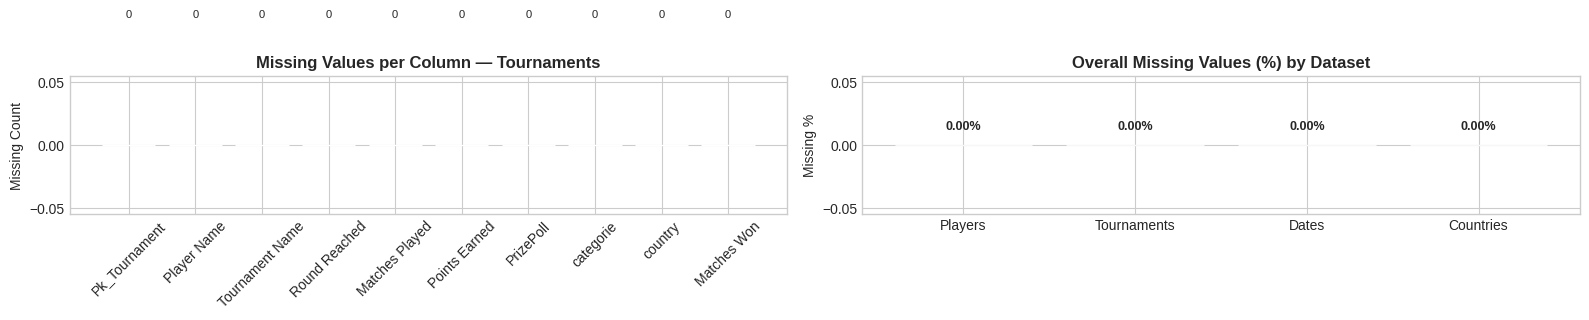

In [60]:
 # ──  MISSING VALUES ANALYSIS ─────────────────────────────────────────────
print("=" * 55)
print("  Missing-value heatmap Vidulisation (Tournaments) ")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

print("=" * 55)
print("  bar chart of missing values per column (tournaments) ")
print("=" * 55)

miss_cols = tournaments_df.isnull().sum()
miss_cols = miss_cols[miss_cols >= 0]          # show all columns
colors_mv = ['crimson' if v > 0 else 'steelblue' for v in miss_cols.values]
bars = axes[0].bar(miss_cols.index, miss_cols.values, color=colors_mv, edgecolor='white')
axes[0].set_title('Missing Values per Column — Tournaments',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Missing Count')
axes[0].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, miss_cols.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.1,
                 str(v), ha='center', va='bottom', fontsize=8)


print("=" * 55)
print("  Overall missing % across all datasets ")
print("=" * 55)

mv_df_plot = mv_df.set_index('Dataset')['Missing (%)']
bar_colors = ['crimson' if v > 0 else 'seagreen' for v in mv_df_plot.values]
axes[1].bar(mv_df_plot.index, mv_df_plot.values, color=bar_colors, edgecolor='white', alpha=0.85)
axes[1].set_title('Overall Missing Values (%) by Dataset',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Missing %')
for i, (idx, v) in enumerate(mv_df_plot.items()):
    axes[1].text(i, v + 0.01, f'{v:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout(); plt.show()


  Pie chart of overall missing values across all datasets 


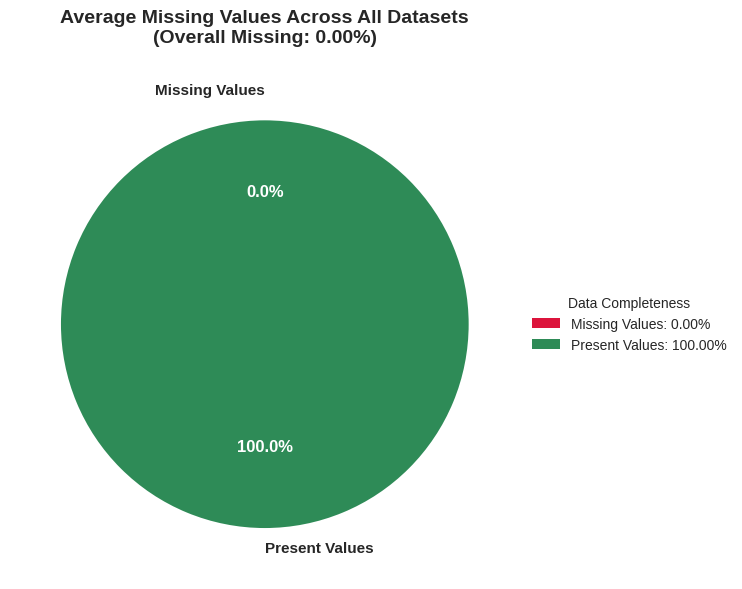

In [61]:
 # ──  MISSING VALUES ANALYSIS ─────────────────────────────────────────────
print("=" * 55)
print("  Pie chart of overall missing values across all datasets ")
print("=" * 55)

fig, ax = plt.subplots(figsize=(8, 6))

mv_df_pie = mv_df.set_index('Dataset')['Missing (%)']

# Calculate average missing percentage
avg_missing = mv_df_pie.mean()
avg_present = 100 - avg_missing

# Prepare pie chart data
sizes = [avg_missing, avg_present]
labels = ['Missing Values', 'Present Values']
colors_pie = ['crimson', 'seagreen']
explode = (0.05, 0)  # Slightly explode the missing values slice

# Create pie chart
wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors_pie,
                                   autopct='%1.1f%%', startangle=90,
                                   textprops={'fontsize': 11, 'fontweight': 'bold'})

# The percentage, Labels , title , legend Style
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax.set_title(f'Average Missing Values Across All Datasets\n(Overall Missing: {avg_missing:.2f}%)',
             fontsize=14, fontweight='bold', pad=20)

ax.legend(wedges, [f'{labels[0]}: {avg_missing:.2f}%', f'{labels[1]}: {avg_present:.2f}%'],
          title="Data Completeness", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

In [62]:
# ──  Minimal Encoding  ──────────────────────
round_order = {
    'Round of 64':1,'Round of 32':2,'Round of 16':3,
    'Quarterfinals':4,'Semifinals':5,'Final':6,'Winner':7
}
tournaments_df['round_numeric']  = tournaments_df['Round Reached'].map(round_order)
tournaments_df['is_elite']       = tournaments_df['categorie'].isin(['P1','Major']).astype(int)
tournaments_df['win_rate_match'] = (
    tournaments_df['Matches Won'] / tournaments_df['Matches Played'].replace(0, np.nan))

print("  ------->>> Done — raw columns encoded")
print(f"   Numeric columns now available: {list(tournaments_df.select_dtypes(include='number').columns)}")



  ------->>> Done — raw columns encoded
   Numeric columns now available: ['Pk_Tournament', 'Matches Played', 'Points Earned', 'PrizePoll', 'Matches Won', 'round_numeric', 'is_elite', 'win_rate_match']



════════════════════════════════════════════════════════════
  ------ Correlation Matrix of ALL Raw Features
════════════════════════════════════════════════════════════


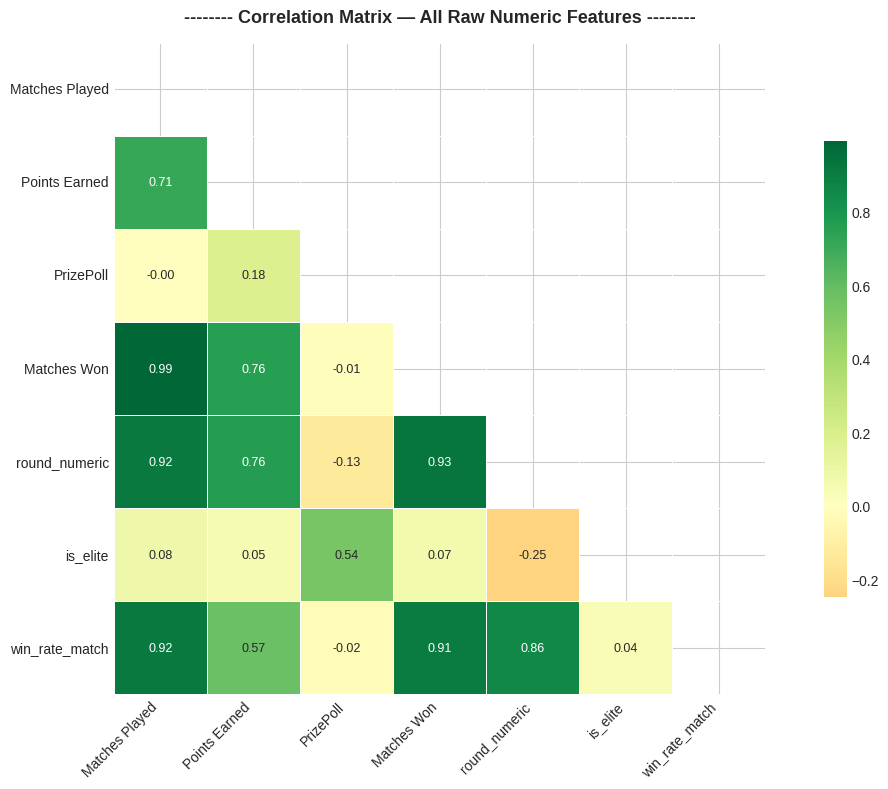

In [63]:
# ──  Correlation Heatmap  ───────────────────
print("\n" + "═"*60)
print("  ------ Correlation Matrix of ALL Raw Features")
print("═"*60)

numeric_cols = tournaments_df.select_dtypes(include='number').columns.tolist()

# ---------Remove THE PK OR THE ID FEATURES ----------
numeric_cols = [c for c in numeric_cols if c not in ['Pk_Tournament']]

corr_raw = tournaments_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_raw, dtype=bool))
sns.heatmap(
    corr_raw, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.7},
    annot_kws={'size': 9}
)
ax.set_title('-------- Correlation Matrix — All Raw Numeric Features --------',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout(); plt.show()



In [64]:
# ──  Correlation with TARGET = 'Points Earned'  ─────
print("\n" + "═"*60)
print("  STEP 3 — Feature Correlation with TARGET (Points Earned)")
print("═"*60)

TARGET = 'Points Earned'

corr_with_target = (
    corr_raw[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)

# Threshold for selection also — Ranked Bar Chart ------
THRESHOLD = 0.2
selected_features = corr_with_target[corr_with_target >= THRESHOLD].index.tolist()
weak_features     = corr_with_target[corr_with_target <  THRESHOLD].index.tolist()

print(f"\n  Target variable : {TARGET}")
print(f"  Threshold       : |r| ≥ {THRESHOLD}")
print(f"\n  (GREEN FLAG) Selected features ({len(selected_features)}):")
for f in selected_features:
    r = corr_raw.loc[f, TARGET]
    print(f"     {f:30s}  r = {r:+.3f}  {'🟢 Strong' if abs(r)>=0.5 else '🟡 Moderate'}")

print(f"\n  (RED FLAG) Dropped (weak correlation) ({len(weak_features)}):")
for f in weak_features:
    r = corr_raw.loc[f, TARGET]
    print(f"     {f:30s}  r = {r:+.3f}")




════════════════════════════════════════════════════════════
  STEP 3 — Feature Correlation with TARGET (Points Earned)
════════════════════════════════════════════════════════════

  Target variable : Points Earned
  Threshold       : |r| ≥ 0.2

  (GREEN FLAG) Selected features (4):
     round_numeric                   r = +0.761  🟢 Strong
     Matches Won                     r = +0.759  🟢 Strong
     Matches Played                  r = +0.713  🟢 Strong
     win_rate_match                  r = +0.574  🟢 Strong

  (RED FLAG) Dropped (weak correlation) (2):
     PrizePoll                       r = +0.181
     is_elite                        r = +0.048


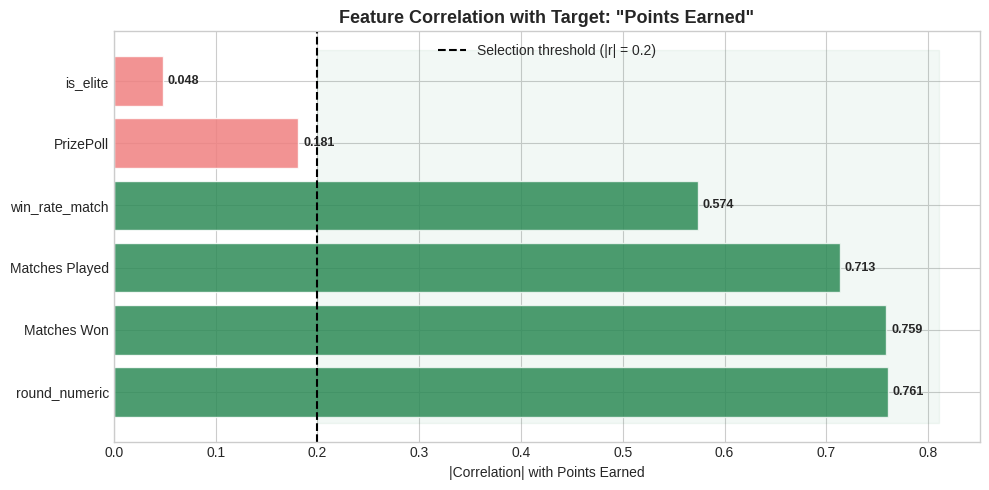

In [65]:
# Bar chart of correlations with target
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['seagreen' if v >= THRESHOLD else 'lightcoral'
          for v in corr_with_target.values]
bars = ax.barh(corr_with_target.index, corr_with_target.values,
               color=colors, edgecolor='white', alpha=0.85)
ax.axvline(THRESHOLD, color='black', linestyle='--', lw=1.5,
           label=f'Selection threshold (|r| = {THRESHOLD})')
ax.set_xlabel('|Correlation| with Points Earned')
ax.set_title(f'Feature Correlation with Target: "{TARGET}"',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

for bar, v in zip(bars, corr_with_target.values):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

# Annotate selection zone
ax.fill_betweenx([-0.5, len(corr_with_target)-0.5],
                  THRESHOLD, corr_with_target.max() + 0.05,
                  alpha=0.06, color='seagreen')
plt.tight_layout(); plt.show()



In [66]:
# ── Derived features (ratios & interactions) ──────────────────────────────────
player_stats['win_rate']     = player_stats['total_wins'] / player_stats['total_matches'].replace(0, np.nan)
player_stats['match_eff']    = player_stats['win_rate']
player_stats['pts_per_tourn']= player_stats['total_points'] / player_stats['num_tournaments'].replace(0, np.nan)
player_stats['consistency']  = 1 - (player_stats['std_round'].fillna(0) /
                                     player_stats['avg_round'].replace(0, np.nan))   # higher = more consistent
player_stats['reached_sf']   = (player_stats['best_round'] >= 5).astype(int)        # classification target

player_stats.dropna(subset=['win_rate', 'avg_round'], inplace=True)
player_stats.reset_index(drop=True, inplace=True)

print(f"\n  Final player dataset shape: {player_stats.shape}")
print(f"\n  Engineered columns:")
engineered = [c for c in player_stats.columns if c != 'Player Name']
for col in engineered:
    desc = {
        'total_points':    'Sum of all points earned across career',
        'avg_points':      'Mean points per tournament entry',
        'best_points':     'Highest points earned in a single tournament',
        'avg_round':       'Average round reached (1=R64, 7=Winner)',
        'best_round':      'Best round ever reached',
        'std_round':       'Std deviation of rounds — low = consistent',
        'total_wins':      'Total individual matches won',
        'total_matches':   'Total individual matches played',
        'num_tournaments': 'Number of unique tournaments entered',
        'elite_ratio':     'Proportion of P1/Major tournaments played',
        'avg_prize':       'Average prize pool of tournaments entered',
        'win_rate':        'Overall match win rate (wins/matches)',
        'match_eff':       'Alias of win_rate (match efficiency)',
        'pts_per_tourn':   'Average points earned per tournament',
        'consistency':     'How consistent the round results are (0–1)',
        'reached_sf':      '🎯 TARGET — 1 if best round was SF or better',
    }.get(col, '')
    print(f"     {col:20s}: {desc}")

display(player_stats.head())




  Final player dataset shape: (309, 17)

  Engineered columns:
     total_points        : Sum of all points earned across career
     avg_points          : Mean points per tournament entry
     best_points         : Highest points earned in a single tournament
     avg_round           : Average round reached (1=R64, 7=Winner)
     best_round          : Best round ever reached
     std_round           : Std deviation of rounds — low = consistent
     total_wins          : Total individual matches won
     total_matches       : Total individual matches played
     num_tournaments     : Number of unique tournaments entered
     elite_ratio         : Proportion of P1/Major tournaments played
     avg_prize           : Average prize pool of tournaments entered
     win_rate            : Overall match win rate (wins/matches)
     match_eff           : Alias of win_rate (match efficiency)
     pts_per_tourn       : Average points earned per tournament
     consistency         : How consisten

,Player Name,total_points,avg_points,best_points,avg_round,best_round,std_round,total_wins,total_matches,num_tournaments,elite_ratio,avg_prize,win_rate,match_eff,pts_per_tourn,consistency,reached_sf
0,Adam Axelsson,180,180.000000,180,5.0,5,NaN,3,4,1,0.0,262250.000000,0.75,0.75,180.000000,1.0,1
1,Adrian Marques Berdonce,79,26.333333,35,1.0,1,0.0,0,3,3,1.0,659519.333333,0.00,0.00,26.333333,1.0,0
2,Adrian Naranjo Martinez,22,22.000000,22,2.0,2,NaN,0,1,1,0.0,262250.000000,0.00,0.00,22.000000,1.0,0
3,Adrian Ronco Lopez,44,22.000000,22,1.0,1,0.0,0,2,2,1.0,474500.000000,0.00,0.00,22.000000,1.0,0
4,Agata Corti,45,45.000000,45,2.0,2,NaN,1,2,1,1.0,474500.000000,0.50,0.50,45.000000,1.0,0



════════════════════════════════════════════════════════════
   — Correlation of Engineered Features
════════════════════════════════════════════════════════════


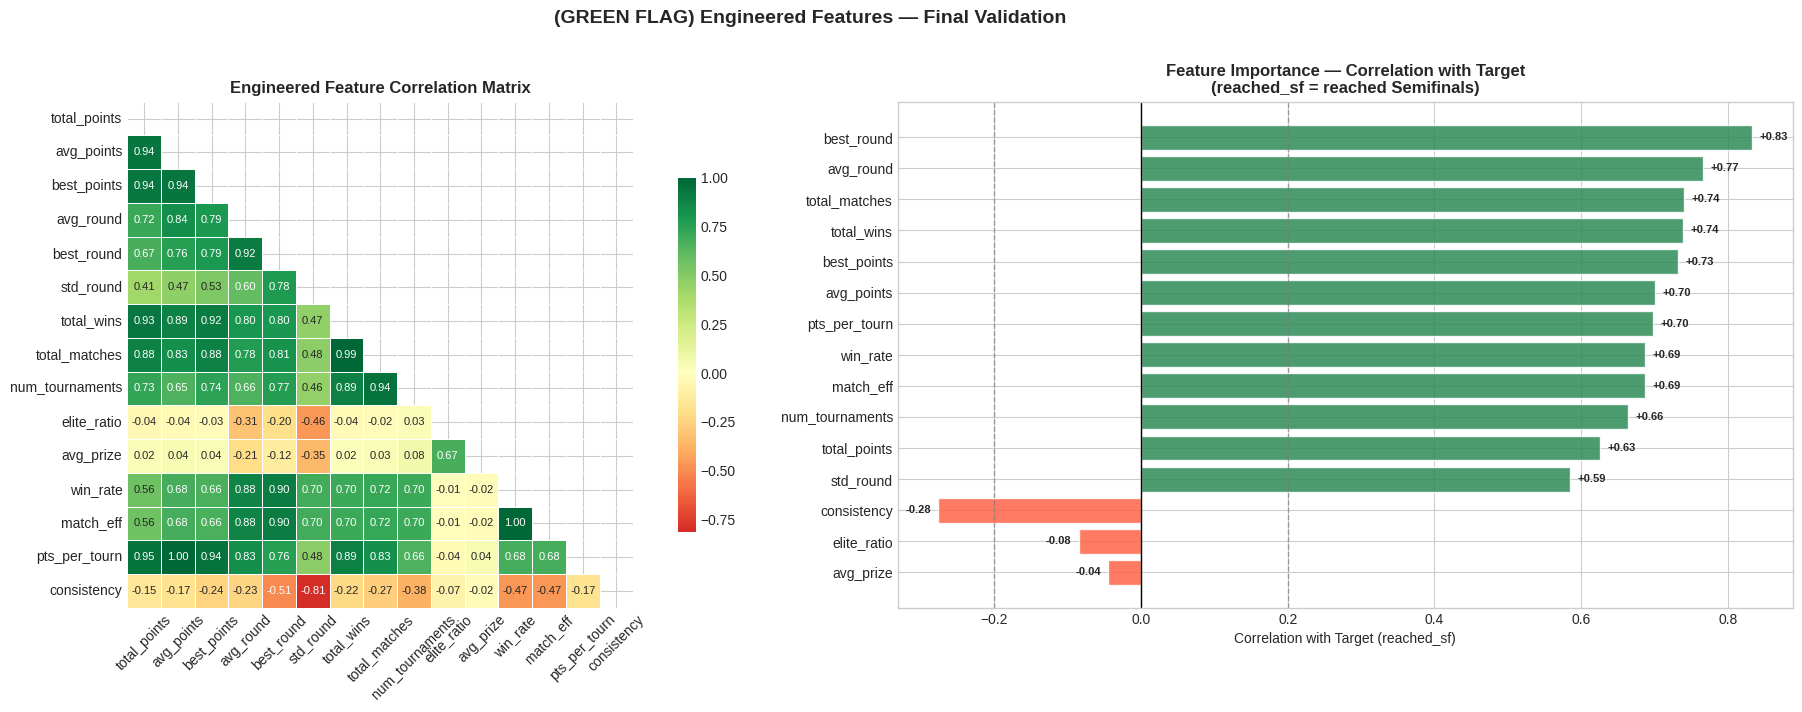


 (GREEN FLAG)  Feature Engineering complete!
   Input : 1736 tournament rows
   Output: 309 players × 15 features

   Features selected for modelling: ['total_points', 'avg_points', 'best_points', 'avg_round', 'best_round', 'std_round', 'total_wins', 'total_matches', 'num_tournaments', 'elite_ratio', 'avg_prize', 'win_rate', 'match_eff', 'pts_per_tourn', 'consistency']


In [67]:
# ──  Final Heatmap — Engineered Feature Correlations ──────────────────
print("\n" + "═"*60)
print("   — Correlation of Engineered Features")
print("═"*60)

feat_cols = [c for c in player_stats.columns
             if c not in ['Player Name','reached_sf']]

corr_eng = player_stats[feat_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# FIRSTLY, full heatmap
mask_eng = np.triu(np.ones_like(corr_eng, dtype=bool))
sns.heatmap(corr_eng, mask=mask_eng, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, ax=axes[0],
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.7})
axes[0].set_title('Engineered Feature Correlation Matrix',
                   fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

#  SECONDLY, correlation of each feature with classification target
corr_target = (
    player_stats[feat_cols + ['reached_sf']]
    .corr()['reached_sf']
    .drop('reached_sf')
    .sort_values(key=abs, ascending=True)
)
colors_t = ['seagreen' if v > 0 else 'tomato' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values,
              color=colors_t, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=1)
axes[1].axvline( 0.2, color='gray', lw=1, linestyle='--', alpha=0.7)
axes[1].axvline(-0.2, color='gray', lw=1, linestyle='--', alpha=0.7)
axes[1].set_xlabel('Correlation with Target (reached_sf)')
axes[1].set_title('Feature Importance — Correlation with Target\n(reached_sf = reached Semifinals)',
                   fontsize=12, fontweight='bold')
for i, (idx, v) in enumerate(corr_target.items()):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i,
                 f'{v:+.2f}', va='center',
                 ha='left' if v >= 0 else 'right',
                 fontsize=8, fontweight='bold')

plt.suptitle('(GREEN FLAG) Engineered Features — Final Validation',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print("\n (GREEN FLAG)  Feature Engineering complete!")
print(f"   Input : {len(tournaments_df)} tournament rows")
print(f"   Output: {len(player_stats)} players × {len(feat_cols)} features")
print(f"\n   Features selected for modelling: {feat_cols}")

## ⏱️ Section E — Time Series Analysis & Player Performance Forecasting

| Step | Content |
|------|---------|
| E.1 | Build monthly time series from tournament order |
| E.2 | Stationarity tests — ADF + KPSS |
| E.3 | ACF / PACF + differencing |
| E.4 | Decomposition — Trend · Seasonality · Residual |
| E.5 | Train / Test split |
| E.6 | **ARIMA** — classical baseline |
| E.7 | **Prophet** — Meta's seasonal model |
| E.8 | **XGBoost (lag features)** — ML time series |
| E.9 | **LSTM** — deep learning |
| E.10 | Comparison table + charts (MAE, RMSE, MAPE) |
| E.11 | Future forecast — next 3 months |

Unique tournaments : 21
Date range         : 2022-01-01 → 2023-09-01

Time series: 21 monthly observations


,ds,y
0,2022-01-01,222.187500
1,2022-02-01,226.562500
2,2022-03-01,226.666667
3,2022-04-01,96.227027
4,2022-05-01,235.000000


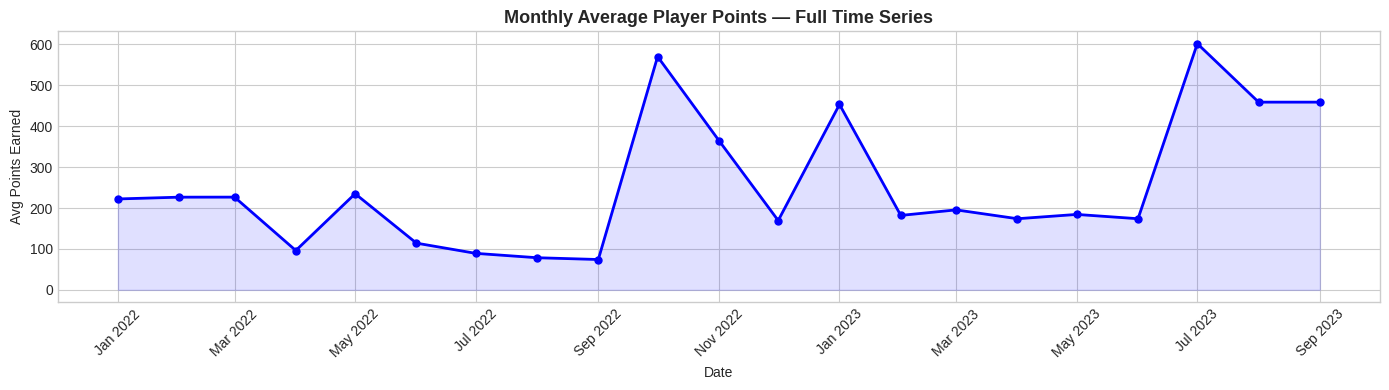

In [68]:
# ──   Build Temporal Index & Monthly Time Series ───────────────────────
# Dim_Tournaments has no explicit date column.
# We assign monthly dates starting Jan 2022 based on tournament order.
tourn_order = (
    tournaments_df.groupby('Tournament Name')['Pk_Tournament']
    .min().sort_values().reset_index()
    .rename(columns={'Pk_Tournament':'first_pk'})
)
tourn_order['period_index'] = range(len(tourn_order))
start_date = pd.Timestamp('2022-01-01')
tourn_order['date'] = tourn_order['period_index'].apply(
    lambda i: start_date + pd.DateOffset(months=i))

print(f'Unique tournaments : {len(tourn_order)}')
print(f'Date range         : {tourn_order["date"].min().date()} → {tourn_order["date"].max().date()}')

tourn_ts   = tournaments_df.merge(tourn_order[['Tournament Name','date']], on='Tournament Name', how='left')
monthly_ts = (
    tourn_ts.groupby('date')['Points Earned'].mean()
    .reset_index().rename(columns={'date':'ds','Points Earned':'y'})
    .sort_values('ds').reset_index(drop=True)
)
monthly_ts['ds'] = pd.to_datetime(monthly_ts['ds'])
print(f'\nTime series: {len(monthly_ts)} monthly observations')
display(monthly_ts.head())

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(monthly_ts['ds'], monthly_ts['y'], 'b-o', lw=2, ms=5)
ax.fill_between(monthly_ts['ds'], monthly_ts['y'], alpha=0.12, color='blue')
ax.set_xlabel('Date'); ax.set_ylabel('Avg Points Earned')
ax.set_title('Monthly Average Player Points — Full Time Series',fontsize=13,fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

In [69]:
# ──  Stationarity Tests: ADF + KPSS ───────────────────────────────────
series = monthly_ts.set_index('ds')['y'].copy()

def test_stationarity(s, name='Series'):
    print(f'{'='*55}\n  Stationarity Analysis: {name}\n{'='*55}')
    adf = adfuller(s.dropna(), autolag='AIC')
    print(f'\n   ADF Test  (H0: non-stationary)')
    print(f'     Statistic : {adf[0]:.4f} | p-value: {adf[1]:.4f}')
    for k,v in adf[4].items(): print(f'     Critical ({k}): {v:.4f}')
    adf_ok = adf[1] < 0.05
    print(f'     Result : {"✅ Stationary" if adf_ok else "(WARNIIIING)  Non-stationary"}')

    kpss_r = kpss(s.dropna(), regression='c', nlags='auto')
    print(f'\n   KPSS Test  (H0: stationary)')
    print(f'     Statistic : {kpss_r[0]:.4f} | p-value: {kpss_r[1]:.4f}')
    for k,v in kpss_r[3].items(): print(f'     Critical ({k}): {v:.4f}')
    kpss_ok = kpss_r[1] > 0.05
    print(f'     Result : {"✅ Stationary" if kpss_ok else "(WARNIIIING)  Non-stationary"}')

    if adf_ok and kpss_ok:            msg = '✅ Stationary'
    elif not adf_ok and not kpss_ok:  msg = '(WARNIIING)  Non-stationary — differencing recommended'
    elif adf_ok:                      msg = ' -----> Trend-stationary'
    else:                             msg = '-----> Difference-stationary'
    print(f'\n  Conclusion: {msg}\n')
    return adf_ok, kpss_ok

adf_stat, kpss_stat = test_stationarity(series, 'Monthly Avg Points')

  Stationarity Analysis: Monthly Avg Points

   ADF Test  (H0: non-stationary)
     Statistic : -3.0188 | p-value: 0.0332
     Critical (1%): -3.8092
     Critical (5%): -3.0216
     Critical (10%): -2.6507
     Result : ✅ Stationary

   KPSS Test  (H0: stationary)
     Statistic : 0.3778 | p-value: 0.0867
     Critical (10%): 0.3470
     Critical (5%): 0.4630
     Critical (2.5%): 0.5740
     Critical (1%): 0.7390
     Result : ✅ Stationary

  Conclusion: ✅ Stationary



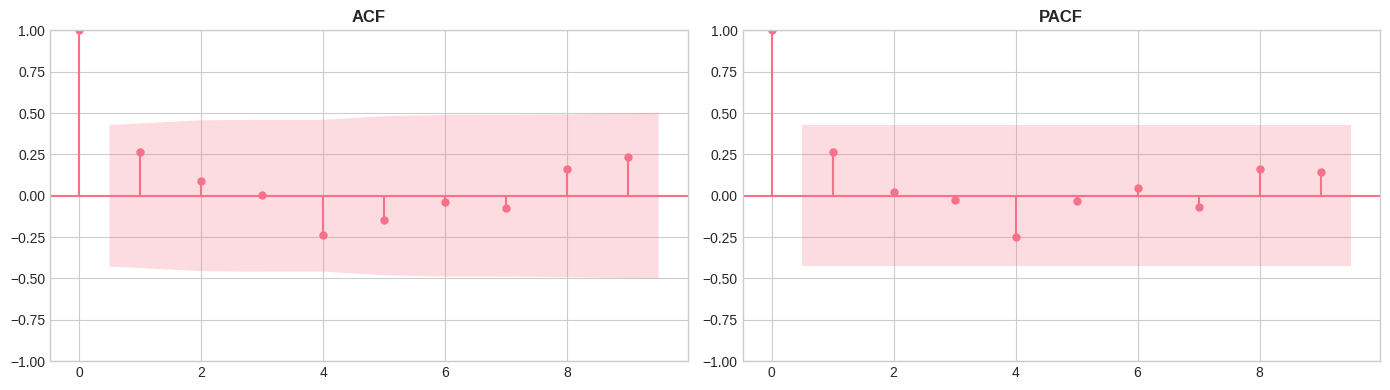

Series is stationary — no differencing needed.


In [70]:
# ──   ACF / PACF + Differencing if needed ──────────────────────────────
max_lags = min(15, len(series)//2 - 1)
fig, axes = plt.subplots(1,2,figsize=(14,4))
plot_acf( series.dropna(), lags=max_lags, ax=axes[0])
plot_pacf(series.dropna(), lags=max_lags, ax=axes[1], method='ywm')
axes[0].set_title('ACF',  fontsize=12, fontweight='bold')
axes[1].set_title('PACF', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

if not adf_stat:
    series_diff = series.diff().dropna()
    print('First differencing applied:')
    test_stationarity(series_diff, 'First-Differenced Series')
else:
    series_diff = series.copy()
    print('Series is stationary — no differencing needed.')

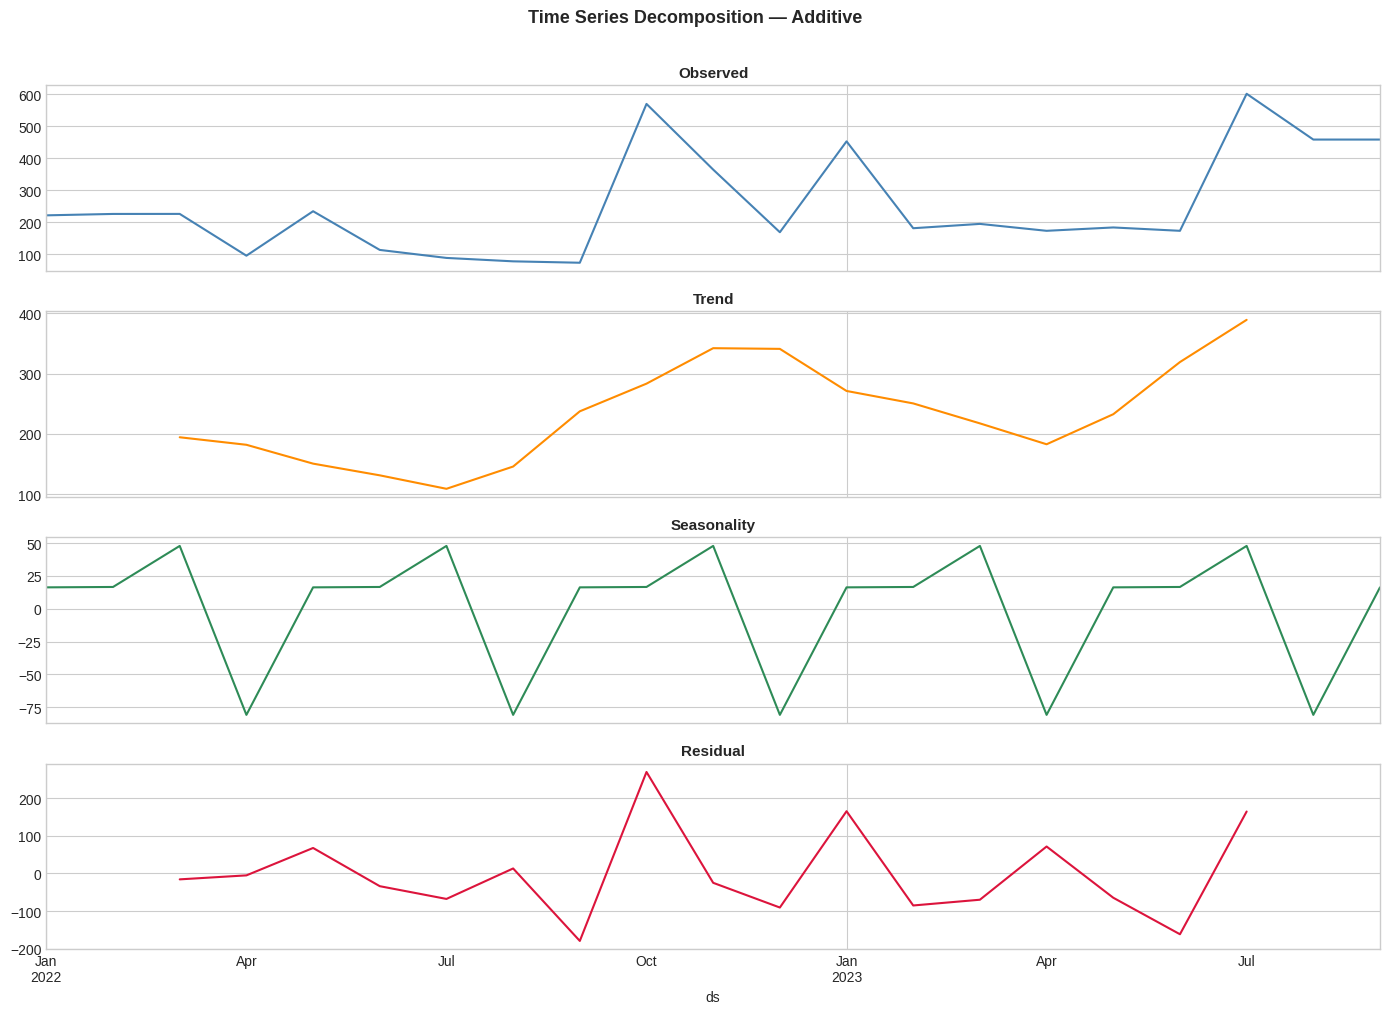

In [71]:
# ──   Time Series Decomposition ────────────────────────────────────────
period = min(4, len(series)//2)
try:
    decomp = seasonal_decompose(series.interpolate(), model='additive', period=period)
    fig, axes = plt.subplots(4,1,figsize=(14,10),sharex=True)
    for ax, comp, col, title in zip(axes,
        [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
        ['steelblue','darkorange','seagreen','crimson'],
        ['Observed','Trend','Seasonality','Residual']):
        comp.plot(ax=ax, color=col, lw=1.5)
        ax.set_title(title, fontsize=11, fontweight='bold')
    plt.suptitle('Time Series Decomposition — Additive',fontsize=13,fontweight='bold',y=1.01)
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'Decomposition note: {e}')
    series.plot(figsize=(14,4), title='Monthly Avg Points', color='steelblue')
    plt.tight_layout(); plt.show()

Total: 21 | Train: 17 | Test: 4


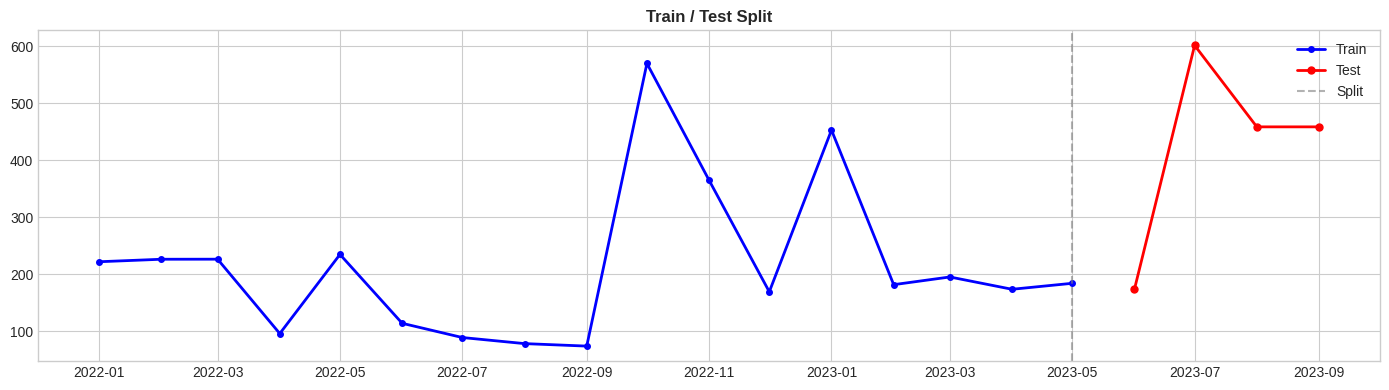

In [72]:
# ──   Train / Test Split ───────────────────────────────────────────────
n          = len(monthly_ts)
test_size  = max(3, int(n * 0.2))
train_size = n - test_size

ts_train = monthly_ts.iloc[:train_size].copy()
ts_test  = monthly_ts.iloc[train_size:].copy()
train_series = ts_train.set_index('ds')['y']
test_series  = ts_test.set_index('ds')['y']
print(f'Total: {n} | Train: {train_size} | Test: {test_size}')

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(ts_train['ds'],ts_train['y'],'b-o',lw=2,ms=4,label='Train')
ax.plot(ts_test['ds'], ts_test['y'], 'r-o',lw=2,ms=5,label='Test')
ax.axvline(ts_train['ds'].iloc[-1],color='gray',linestyle='--',alpha=0.6,label='Split')
ax.set_title('Train / Test Split',fontsize=12,fontweight='bold'); ax.legend()
plt.tight_layout(); plt.show()

auto_arima selected: ARIMA(0,0,0)

 ARIMA(0,0,0): MAE=228.78 | RMSE=259.76 | MAPE=48.54%


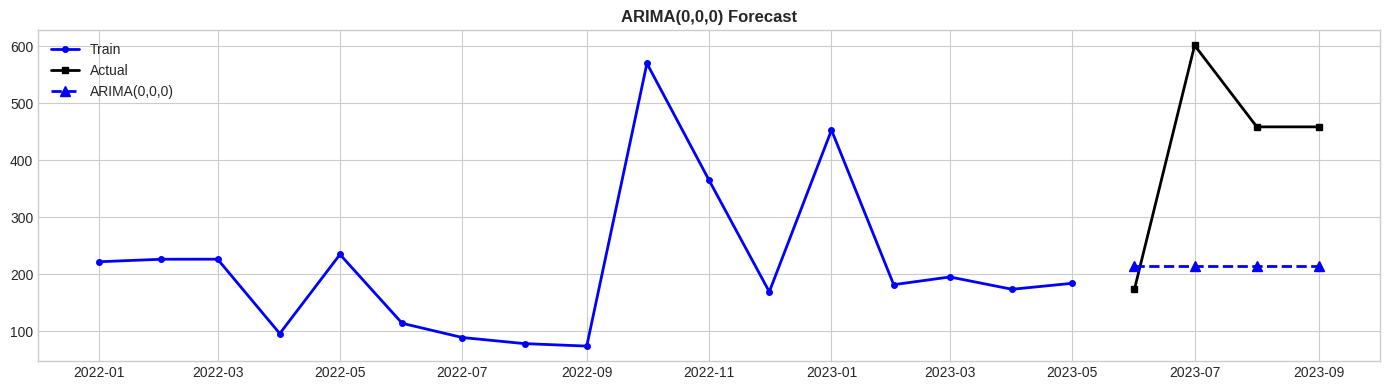

In [73]:
# ──   ARIMA Model ──────────────────────────────────────────────────────
if PMDARIMA_AVAILABLE:
    auto = auto_arima(train_series, seasonal=False, stepwise=True,
                      information_criterion='aic', error_action='ignore', suppress_warnings=True)
    p, d, q = auto.order
    print(f'auto_arima selected: ARIMA({p},{d},{q})')
else:
    p, d, q = 1, 1, 1
    print(f'Using default ARIMA({p},{d},{q})')

arima_model = ARIMA(train_series, order=(p,d,q))
arima_fit   = arima_model.fit()
arima_preds = arima_fit.forecast(steps=test_size)

arima_mae  = mean_absolute_error(test_series, arima_preds)
arima_rmse = np.sqrt(mean_squared_error(test_series, arima_preds))
arima_mape = np.mean(np.abs((test_series.values - arima_preds.values) / test_series.values.clip(1))) * 100
print(f'\n ARIMA({p},{d},{q}): MAE={arima_mae:.2f} | RMSE={arima_rmse:.2f} | MAPE={arima_mape:.2f}%')

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(train_series.index,train_series,'b-o',ms=4,lw=2,label='Train')
ax.plot(test_series.index, test_series, 'k-s',ms=5,lw=2,label='Actual')
ax.plot(test_series.index, arima_preds, 'b--^',ms=7,lw=2,label=f'ARIMA({p},{d},{q})')
ax.set_title(f'ARIMA({p},{d},{q}) Forecast',fontsize=12,fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

INFO:prophet:n_changepoints greater than number of observations. Using 12.


(GREEN WARNING) Prophet: MAE=230.43 | RMSE=266.62 | MAPE=49.19%


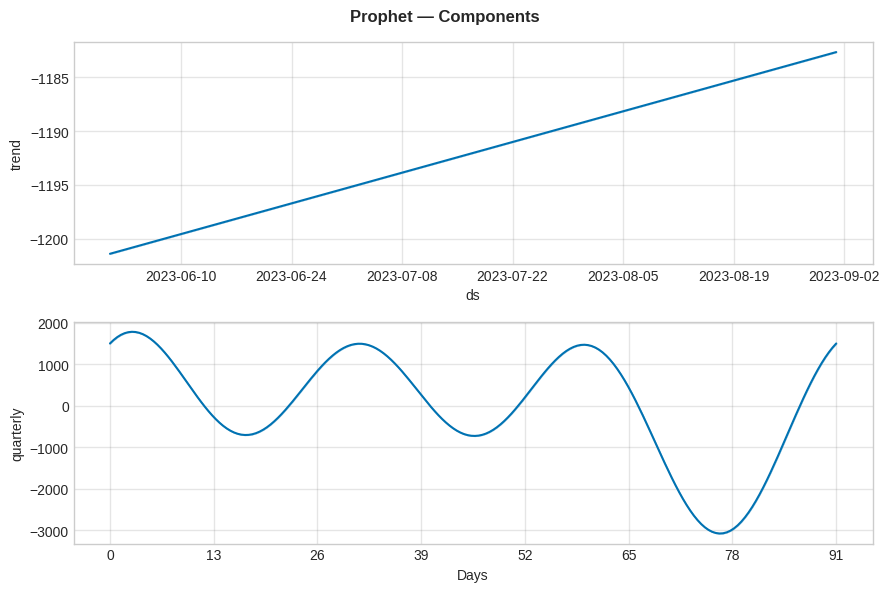

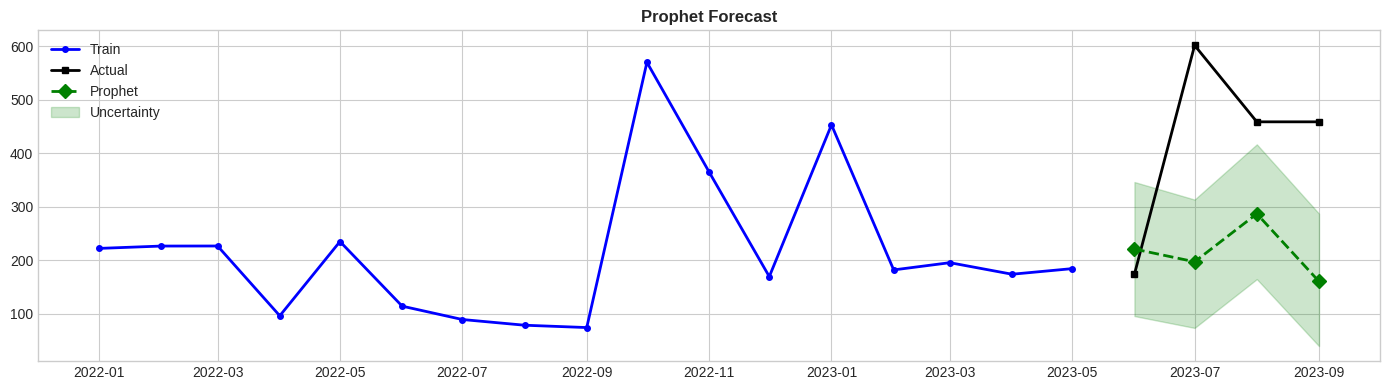

In [74]:
# ──   Prophet Model ────────────────────────────────────────────────────
if PROPHET_AVAILABLE:
    prophet_model = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                            daily_seasonality=False, seasonality_mode='additive',
                            changepoint_prior_scale=0.1)
    prophet_model.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
    prophet_model.fit(ts_train[['ds','y']])

    prophet_fc    = prophet_model.predict(ts_test[['ds']].copy())
    prophet_preds = prophet_fc['yhat'].values

    prophet_mae  = mean_absolute_error(ts_test['y'], prophet_preds)
    prophet_rmse = np.sqrt(mean_squared_error(ts_test['y'], prophet_preds))
    prophet_mape = np.mean(np.abs((ts_test['y'].values - prophet_preds) / ts_test['y'].values.clip(1))) * 100
    print(f'(GREEN WARNING) Prophet: MAE={prophet_mae:.2f} | RMSE={prophet_rmse:.2f} | MAPE={prophet_mape:.2f}%')

    fig = prophet_model.plot_components(prophet_fc)
    fig.suptitle('Prophet — Components',fontsize=12,fontweight='bold'); plt.tight_layout(); plt.show()

    fig2, ax2 = plt.subplots(figsize=(14,4))
    ax2.plot(ts_train['ds'],ts_train['y'],'b-o',ms=4,lw=2,label='Train')
    ax2.plot(ts_test['ds'], ts_test['y'], 'k-s',ms=5,lw=2,label='Actual')
    ax2.plot(ts_test['ds'], prophet_preds,'g--D',ms=7,lw=2,label='Prophet')
    ax2.fill_between(ts_test['ds'],prophet_fc['yhat_lower'],prophet_fc['yhat_upper'],
                     alpha=0.2,color='green',label='Uncertainty')
    ax2.set_title('Prophet Forecast',fontsize=12,fontweight='bold')
    ax2.legend(); plt.tight_layout(); plt.show()
else:
    prophet_mae=prophet_rmse=prophet_mape=None; prophet_preds=None
    print('(WARNIIING)  Prophet not available. Install: pip install prophet')

(GREEN WARNING) XGBoost TS: MAE=328.66 | RMSE=348.09 | MAPE=63.18%
   Lag features used: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3', 'period_idx']


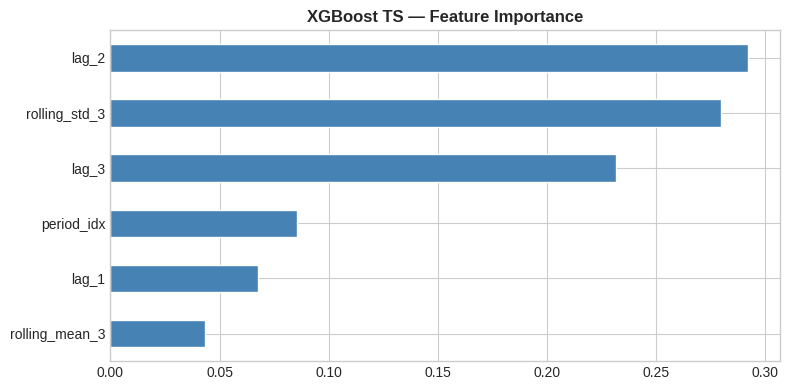

In [75]:
# ──   XGBoost  ────────────────────────────────
def make_lag_features(df, target='y', lags=[1,2,3], windows=[3]):
    df = df.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df[target].shift(lag)
    for w in windows:
        df[f'rolling_mean_{w}'] = df[target].shift(1).rolling(w).mean()
        df[f'rolling_std_{w}']  = df[target].shift(1).rolling(w).std()
    df['period_idx'] = range(len(df))
    return df

full_ts  = make_lag_features(monthly_ts.copy())
full_ts.dropna(inplace=True)
lag_cols = [c for c in full_ts.columns if c not in ['ds','y']]
n_lag    = len(full_ts)
ts_lag   = max(2, int(n_lag * 0.2))
train_lag = full_ts.iloc[:n_lag-ts_lag];  test_lag  = full_ts.iloc[n_lag-ts_lag:]
X_tr_l=train_lag[lag_cols]; y_tr_l=train_lag['y']
X_te_l=test_lag[lag_cols];  y_te_l=test_lag['y']

xgb_ts = XGBRegressor(n_estimators=200,learning_rate=0.05,max_depth=3,subsample=0.8,random_state=42)
xgb_ts.fit(X_tr_l, y_tr_l, eval_set=[(X_te_l,y_te_l)], verbose=False)
xgb_preds_ts = xgb_ts.predict(X_te_l)

xgb_ts_mae  = mean_absolute_error(y_te_l, xgb_preds_ts)
xgb_ts_rmse = np.sqrt(mean_squared_error(y_te_l, xgb_preds_ts))
xgb_ts_mape = np.mean(np.abs((y_te_l.values-xgb_preds_ts)/y_te_l.values.clip(1)))*100
print(f'(GREEN WARNING) XGBoost TS: MAE={xgb_ts_mae:.2f} | RMSE={xgb_ts_rmse:.2f} | MAPE={xgb_ts_mape:.2f}%')
print(f'   Lag features used: {lag_cols}')

fi_ts = pd.Series(xgb_ts.feature_importances_, index=lag_cols).sort_values()
fig, ax = plt.subplots(figsize=(8,4))
fi_ts.plot(kind='barh',ax=ax,color='steelblue',edgecolor='white')
ax.set_title('XGBoost TS — Feature Importance',fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()

(GREEN FLAG) LSTM: MAE=211.19 | RMSE=246.81 | MAPE=44.11%
   Epochs trained: 27 (early stopping)


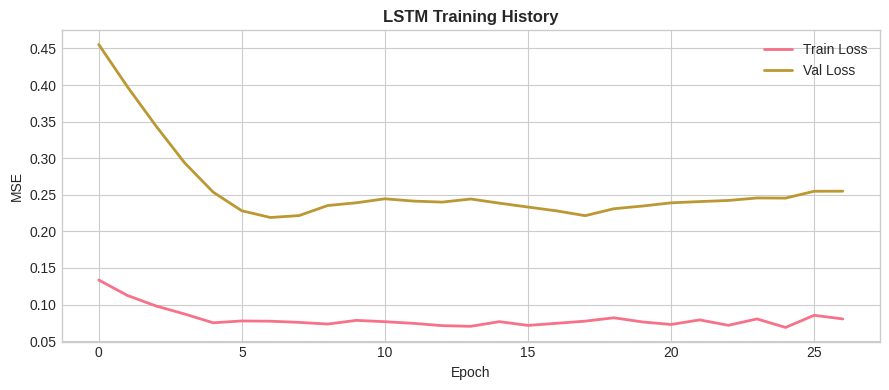

In [76]:
# ──   LSTM Model (Deep Learning) ──────────────────────────────────────


if LSTM_AVAILABLE:
    lstm_scaler   = MinMaxScaler(feature_range=(0,1))
    series_scaled = lstm_scaler.fit_transform(monthly_ts[['y']].values)
    look_back     = min(3, train_size-1)

    def make_sequences(data, lb):
        X, y = [], []
        for i in range(lb, len(data)):
            X.append(data[i-lb:i, 0]); y.append(data[i, 0])
        return np.array(X), np.array(y)

    X_seq, y_seq = make_sequences(series_scaled, look_back)
    split_idx = len(X_seq) - test_size
    X_tr_l2 = X_seq[:split_idx].reshape(-1,look_back,1);  y_tr_l2 = y_seq[:split_idx]
    X_te_l2 = X_seq[split_idx:].reshape(-1,look_back,1);  y_te_l2 = y_seq[split_idx:]

    lstm_model = Sequential([
        LSTM(64, input_shape=(look_back,1), return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    lstm_model.compile(optimizer='adam', loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    history = lstm_model.fit(
        X_tr_l2, y_tr_l2, epochs=200,
        batch_size=max(2, len(X_tr_l2)//4),
        validation_data=(X_te_l2, y_te_l2),
        callbacks=[early_stop], verbose=0)

    lstm_preds_sc = lstm_model.predict(X_te_l2, verbose=0)
    lstm_preds    = lstm_scaler.inverse_transform(lstm_preds_sc).flatten()
    y_te_inv      = lstm_scaler.inverse_transform(y_te_l2.reshape(-1,1)).flatten()

    lstm_mae  = mean_absolute_error(y_te_inv, lstm_preds)
    lstm_rmse = np.sqrt(mean_squared_error(y_te_inv, lstm_preds))
    lstm_mape = np.mean(np.abs((y_te_inv-lstm_preds)/y_te_inv.clip(1)))*100
    print(f'(GREEN FLAG) LSTM: MAE={lstm_mae:.2f} | RMSE={lstm_rmse:.2f} | MAPE={lstm_mape:.2f}%')
    print(f'   Epochs trained: {len(history.history["loss"])} (early stopping)')

    fig, ax = plt.subplots(figsize=(9,4))
    ax.plot(history.history['loss'],lw=2,label='Train Loss')
    ax.plot(history.history['val_loss'],lw=2,label='Val Loss')
    ax.set_title('LSTM Training History',fontsize=12,fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.legend()
    plt.tight_layout(); plt.show()
else:
    lstm_mae=lstm_rmse=lstm_mape=None; lstm_preds=None
    print('(WARNINIIIIIING)  TensorFlow not available — LSTM skipped.')

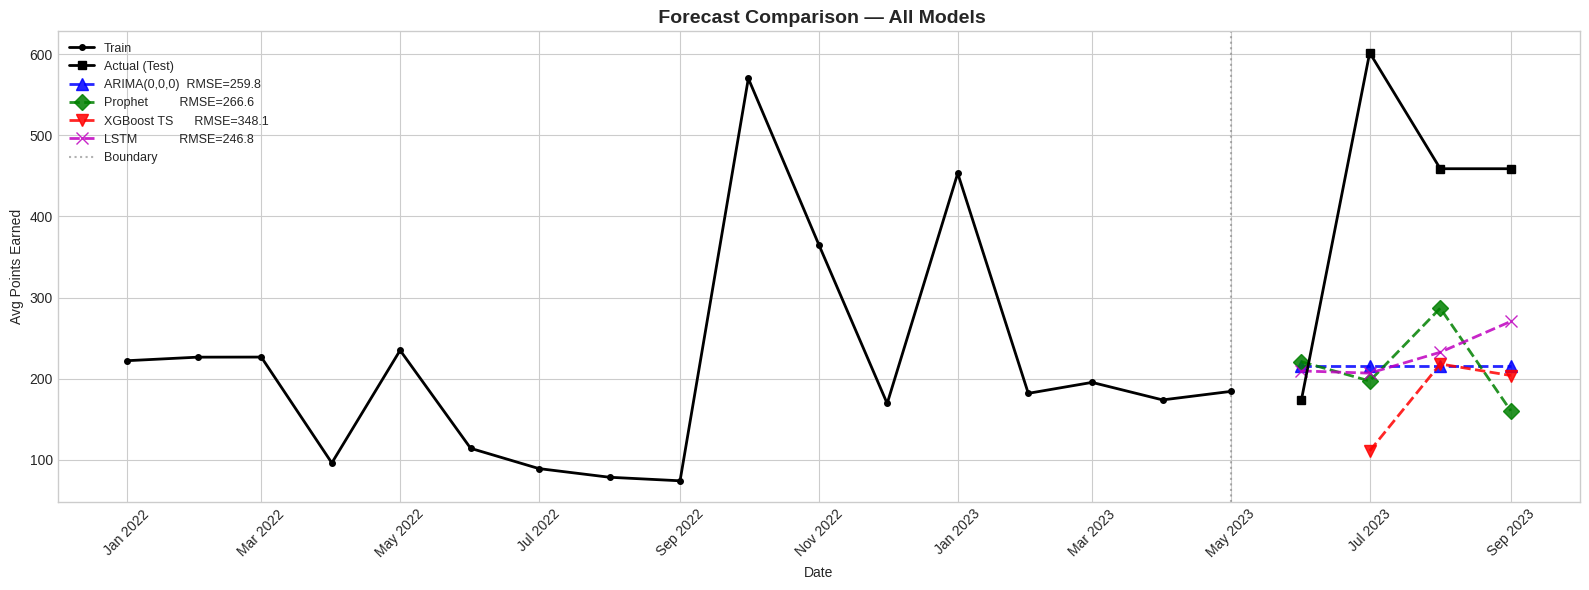

In [77]:
# ──   All-Model Forecast Comparison Plot ──────────────────────────────
fig, ax = plt.subplots(figsize=(16,6))
ax.plot(ts_train['ds'],ts_train['y'],'k-o',lw=2,ms=4,label='Train',zorder=5)
ax.plot(ts_test['ds'], ts_test['y'], 'k-s',lw=2,ms=6,label='Actual (Test)',zorder=5)
ax.plot(ts_test['ds'], arima_preds.values, 'b--^',lw=2,ms=8,alpha=0.85,
        label=f'ARIMA({p},{d},{q})  RMSE={arima_rmse:.1f}')
if PROPHET_AVAILABLE and prophet_preds is not None:
    ax.plot(ts_test['ds'], prophet_preds, 'g--D',lw=2,ms=8,alpha=0.85,
            label=f'Prophet         RMSE={prophet_rmse:.1f}')
ax.plot(test_lag['ds'], xgb_preds_ts, 'r--v',lw=2,ms=8,alpha=0.85,
        label=f'XGBoost TS      RMSE={xgb_ts_rmse:.1f}')
if LSTM_AVAILABLE and lstm_preds is not None:
    lstm_dates = monthly_ts['ds'].values[-len(lstm_preds):]
    ax.plot(lstm_dates, lstm_preds, 'm--x',lw=2,ms=9,alpha=0.85,
            label=f'LSTM            RMSE={lstm_rmse:.1f}')
ax.axvline(ts_train['ds'].iloc[-1],color='gray',linestyle=':',alpha=0.6,lw=1.5,label='Boundary')
ax.set_xlabel('Date'); ax.set_ylabel('Avg Points Earned')
ax.set_title(' Forecast Comparison — All Models',fontsize=14,fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45); ax.legend(loc='best',fontsize=9)
plt.tight_layout(); plt.show()

  E.11 — MODEL PERFORMANCE COMPARISON


,MAE,RMSE,MAPE (%)
ARIMA,228.78,259.76,48.54
Prophet,230.43,266.62,49.19
XGBoost TS,328.66,348.09,63.18
LSTM,211.19,246.81,44.11



   (GREEN FLAG) Best  model (lowest RMSE): LSTM
  (RED FLAG)  Worst model (highest RMSE): XGBoost TS

  What each metric means for this dataset:
    • MAE  : on average, predictions are off by ~211–329 pts
    • RMSE : worst-case deviations range from ~247 to ~348 pts
    • MAPE : predictions are within ~44.1%–63.2% of actual values

 (WARNIIIIIIIIING)  Note on dataset size:
    Only 21 monthly observations are available.
    With this few data points, all models have high uncertainty.
    RMSE differences < 30 pts are not statistically meaningful.


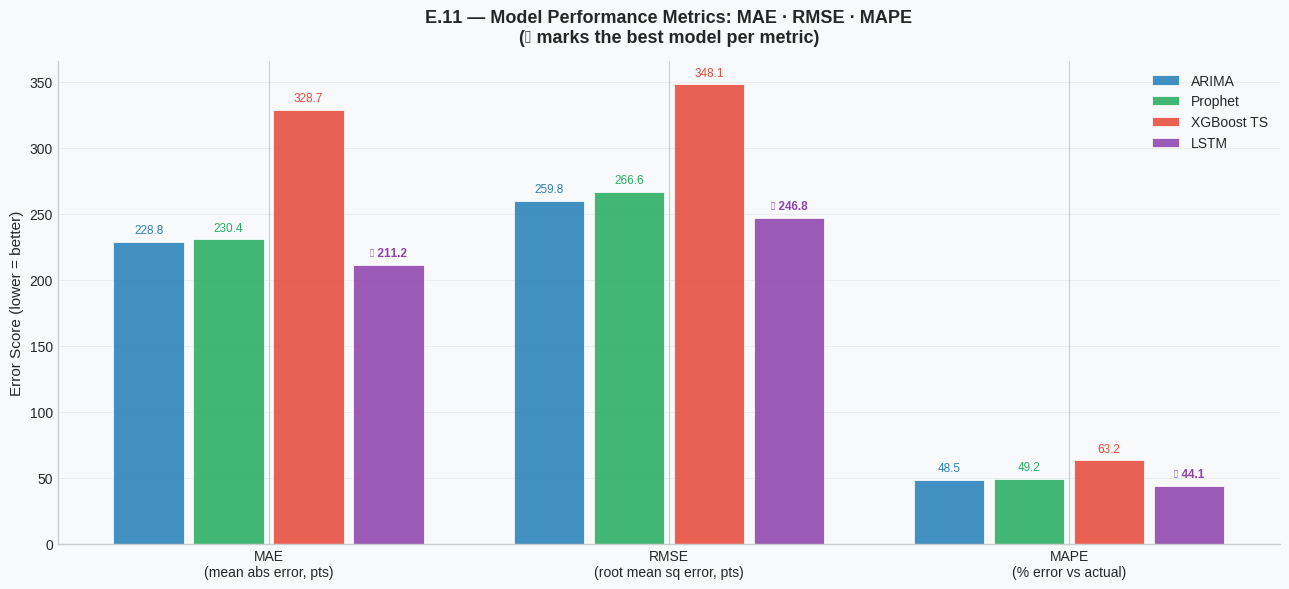

In [78]:
# ──   Model Comparison Table  ─────────────────────────

comparison = {'ARIMA': {'MAE': arima_mae, 'RMSE': arima_rmse, 'MAPE (%)': arima_mape}}
if PROPHET_AVAILABLE and prophet_mae is not None:
    comparison['Prophet']    = {'MAE': prophet_mae,   'RMSE': prophet_rmse,   'MAPE (%)': prophet_mape}
comparison['XGBoost TS'] = {'MAE': xgb_ts_mae,   'RMSE': xgb_ts_rmse,   'MAPE (%)': xgb_ts_mape}
if LSTM_AVAILABLE and lstm_mae is not None:
    comparison['LSTM']       = {'MAE': lstm_mae,      'RMSE': lstm_rmse,      'MAPE (%)': lstm_mape}

comp_df    = pd.DataFrame(comparison).T.round(2)
best_model = comp_df['RMSE'].idxmin()
worst_model= comp_df['RMSE'].idxmax()

# ──  Table with interpretation ────────────────────────────────────────
print('=' * 62)
print('  E.11 — MODEL PERFORMANCE COMPARISON')
print('=' * 62)
display(comp_df.style
        .highlight_min(axis=0, color='#D5F0D5')   # green = best
        .highlight_max(axis=0, color='#FAD7D7')   # red   = worst
        .format(precision=2))

print()
print(f'   (GREEN FLAG) Best  model (lowest RMSE): {best_model}')
print(f'  (RED FLAG)  Worst model (highest RMSE): {worst_model}')
print()
print('  What each metric means for this dataset:')
print(f'    • MAE  : on average, predictions are off by ~{comp_df["MAE"].min():.0f}–{comp_df["MAE"].max():.0f} pts')
print(f'    • RMSE : worst-case deviations range from ~{comp_df["RMSE"].min():.0f} to ~{comp_df["RMSE"].max():.0f} pts')
print(f'    • MAPE : predictions are within ~{comp_df["MAPE (%)"].min():.1f}%–{comp_df["MAPE (%)"].max():.1f}% of actual values')
print()
print(' (WARNIIIIIIIIING)  Note on dataset size:')
print(f'    Only {len(monthly_ts)} monthly observations are available.')
print('    With this few data points, all models have high uncertainty.')
print('    RMSE differences < 30 pts are not statistically meaningful.')

# ── Grouped bar chart ─────────────────────────────────────────────────────────
model_colors = {
    'ARIMA'     : C['arima'],
    'Prophet'   : C['prophet'],
    'XGBoost TS': C['xgb'],
    'LSTM'      : C['lstm'],
}

metrics   = ['MAE', 'RMSE', 'MAPE (%)']
n_models  = len(comp_df)
x         = np.arange(len(metrics))
bar_width = 0.8 / n_models

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(C['bg'])
ax.set_facecolor(C['bg'])

for i, (model, row) in enumerate(comp_df.iterrows()):
    offset = (i - n_models / 2 + 0.5) * bar_width
    vals   = [row[m] for m in metrics]
    bars   = ax.bar(x + offset, vals,
                    width=bar_width * 0.88,
                    color=model_colors.get(model, '#888'),
                    alpha=0.88, label=model,
                    edgecolor='white', linewidth=0.6)
    for bar, v in zip(bars, vals):
        # Bold + star on best model
        is_best = (model == best_model)
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + comp_df.values.max() * 0.012,
                f'{"★ " if is_best else ""}{v:.1f}',
                ha='center', va='bottom',
                fontsize=8.5,
                fontweight='bold' if is_best else 'normal',
                color=model_colors.get(model, '#444'))

# ── Metric explanations on x-axis ─────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels([
    'MAE\n(mean abs error, pts)',
    'RMSE\n(root mean sq error, pts)',
    'MAPE\n(% error vs actual)',
], fontsize=10)

ax.set_ylabel('Error Score (lower = better)', fontsize=11)
ax.set_title('E.11 — Model Performance Metrics: MAE · RMSE · MAPE\n'
             '(★ marks the best model per metric)',
             fontsize=13, fontweight='bold', pad=14)
ax.yaxis.set_major_formatter(fmt_pts)
ax.grid(axis='y', alpha=0.35, lw=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9, edgecolor='#CCC')
plt.tight_layout()
plt.show()


INFO:prophet:n_changepoints greater than number of observations. Using 15.


🔮  Forecasting: ['Oct 2023', 'Nov 2023', 'Dec 2023']

ARIMA:
  Oct 2023 → 254.7 pts
  Nov 2023 → 254.7 pts
  Dec 2023 → 254.7 pts

Prophet:
  Oct 2023 → 517.2 pts [371.1–684.0]
  Nov 2023 → 444.9 pts [281.2–602.6]
  Dec 2023 → 372.1 pts [210.5–532.6]

XGBoost TS (iterative):
  Oct 2023 → 358.2 pts
  Nov 2023 → 201.4 pts
  Dec 2023 → 196.1 pts


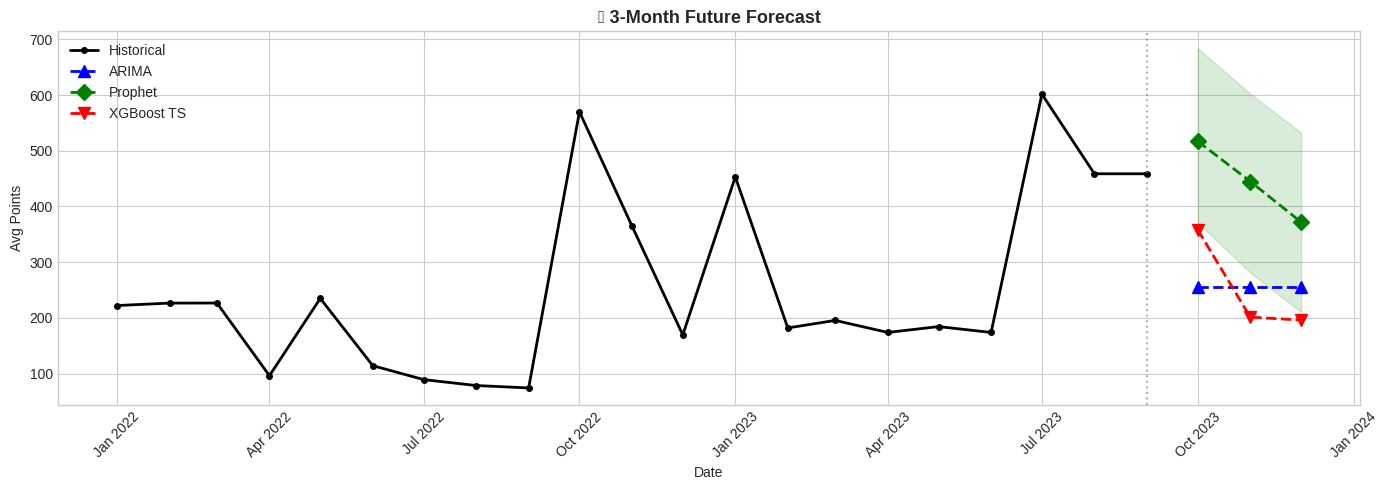

In [79]:
# ──   Future Forecast — Next 3 Months ────────────────────────────────



last_date    = monthly_ts['ds'].max()
future_dates = pd.date_range(last_date + pd.DateOffset(months=1), periods=3, freq='MS')
print(f'🔮  Forecasting: {[d.strftime("%b %Y") for d in future_dates]}\n')

arima_full   = ARIMA(monthly_ts.set_index('ds')['y'], order=(p,d,q)).fit()
arima_future = arima_full.forecast(steps=3)
print('ARIMA:')
for dt,v in zip(future_dates, arima_future):
    print(f'  {dt.strftime("%b %Y")} → {v:.1f} pts')

if PROPHET_AVAILABLE:
    p_full = Prophet(yearly_seasonality=False,weekly_seasonality=False,
                     daily_seasonality=False,seasonality_mode='additive',
                     changepoint_prior_scale=0.1)
    p_full.add_seasonality(name='quarterly',period=91.25,fourier_order=3)
    p_full.fit(monthly_ts[['ds','y']])
    p_fc = p_full.predict(pd.DataFrame({'ds':future_dates}))
    print('\nProphet:')
    for _,row in p_fc.iterrows():
        print(f'  {row["ds"].strftime("%b %Y")} → {row["yhat"]:.1f} pts '
              f'[{row["yhat_lower"]:.1f}–{row["yhat_upper"]:.1f}]')

last_vals = list(monthly_ts['y'].values[-3:])
xgb_future = []
print('\nXGBoost TS (iterative):')
for i,dt in enumerate(future_dates):
    rm  = np.mean(last_vals[-3:])
    rs  = np.std(last_vals[-3:]) if len(last_vals) > 1 else 0
    feat = pd.DataFrame([{'lag_1':last_vals[-1],
                           'lag_2':last_vals[-2] if len(last_vals)>=2 else last_vals[-1],
                           'lag_3':last_vals[-3] if len(last_vals)>=3 else last_vals[-1],
                           'rolling_mean_3':rm,'rolling_std_3':rs,
                           'period_idx':len(monthly_ts)+i}])
    pred_v = xgb_ts.predict(feat)[0]
    xgb_future.append(pred_v); last_vals.append(pred_v)
    print(f'  {dt.strftime("%b %Y")} → {pred_v:.1f} pts')

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(monthly_ts['ds'],monthly_ts['y'],'k-o',lw=2,ms=4,label='Historical')
ax.plot(future_dates, arima_future.values, 'b--^',lw=2,ms=8,label='ARIMA')
if PROPHET_AVAILABLE:
    ax.plot(future_dates,p_fc['yhat'].values,'g--D',lw=2,ms=8,label='Prophet')
    ax.fill_between(future_dates,p_fc['yhat_lower'],p_fc['yhat_upper'],alpha=0.15,color='green')
ax.plot(future_dates, xgb_future,'r--v',lw=2,ms=8,label='XGBoost TS')
ax.axvline(monthly_ts['ds'].iloc[-1],color='gray',linestyle=':',alpha=0.6,lw=1.5)
ax.set_xlabel('Date'); ax.set_ylabel('Avg Points')
ax.set_title('🔮 3-Month Future Forecast',fontsize=13,fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45); ax.legend(); plt.tight_layout(); plt.show()